# IndiGo Hub & Network Intelligence


Goal:
Analyze IndiGo's route network using graph theory and identify strategic hubs, bottlenecks, and expansion opportunities.

In [ ]:
import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
indigo = pd.read_csv(
    "indigo_profitability.csv"
)

indigo.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment,Source_Airport_Name,Source_City,Source_Country,Source_Latitude,Source_Longitude,Destination_Airport_Name,Destination_City,Destination_Country,Destination_Latitude,Destination_Longitude,Route,Route_Type,Aircraft_Capacity,Load_Factor,Passengers,Avg_Ticket_Price,Revenue,Fuel_Cost,Airport_Charges,Crew_Cost,Maintenance_Cost,Operating_Cost,Profit,Profit_Margin,Flights_Per_Day,Flights_Per_Year,Profit_Category
0,6E,2850.0,AMD,2994.0,BLR,3131.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Kempegowda International Airport,Bangalore,India,13.197900,77.706299,Sardar Vallabhbhai Patel International Airport...,Domestic,218,0.723238,157,6856,2357298480,465798,206299,36256,57658,1397970075,959328405,40.696094,5,1825,High Profit
1,6E,2850.0,AMD,2994.0,BOM,2997.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Chhatrapati Shivaji International Airport,Mumbai,India,19.088699,72.867897,Sardar Vallabhbhai Patel International Airport...,Domestic,208,0.700487,145,7545,1597276500,682238,187050,106256,31852,367699540,1229576960,76.979594,1,365,High Profit
2,6E,2850.0,AMD,2994.0,CCU,3043.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Netaji Subhash Chandra Bose International Airport,Kolkata,India,22.654699,88.446701,Sardar Vallabhbhai Patel International Airport...,Domestic,194,0.715629,138,4743,1672334370,319735,67153,63937,27551,1222250680,450083690,26.913499,7,2555,Medium Profit
3,6E,2850.0,AMD,2994.0,DEL,3093.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Indira Gandhi International Airport,Delhi,India,28.566500,77.103104,Sardar Vallabhbhai Patel International Airport...,Domestic,222,0.817431,181,8688,2295890880,355683,109765,31651,96947,1517787530,778103350,33.891129,7,2555,Medium Profit
4,6E,2850.0,AMD,2994.0,GOI,3007.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Dabolim Airport,Goa,India,15.380800,73.831398,Sardar Vallabhbhai Patel International Airport...,Domestic,187,0.771151,144,6618,1739210400,736437,158212,80288,86001,2710696590,-971486190,-55.857888,7,2555,Low Profit


In [ ]:
print(indigo.shape)

(199, 36)


In [ ]:
G = nx.DiGraph()

for _, row in indigo.iterrows():

    G.add_edge(
        row["Source_Airport_Name"],
        row["Destination_Airport_Name"]
    )

In [ ]:
print("Nodes (Airports):", G.number_of_nodes())

print("Edges (Routes):", G.number_of_edges())

Nodes (Airports): 35
Edges (Routes): 199


In [ ]:
airport_labels = {}

for _, row in indigo.iterrows():
    airport_labels[row["Source_Airport_Name"]] = row["Source_Airport"]
    airport_labels[row["Destination_Airport_Name"]] = row["Destination_Airport"]

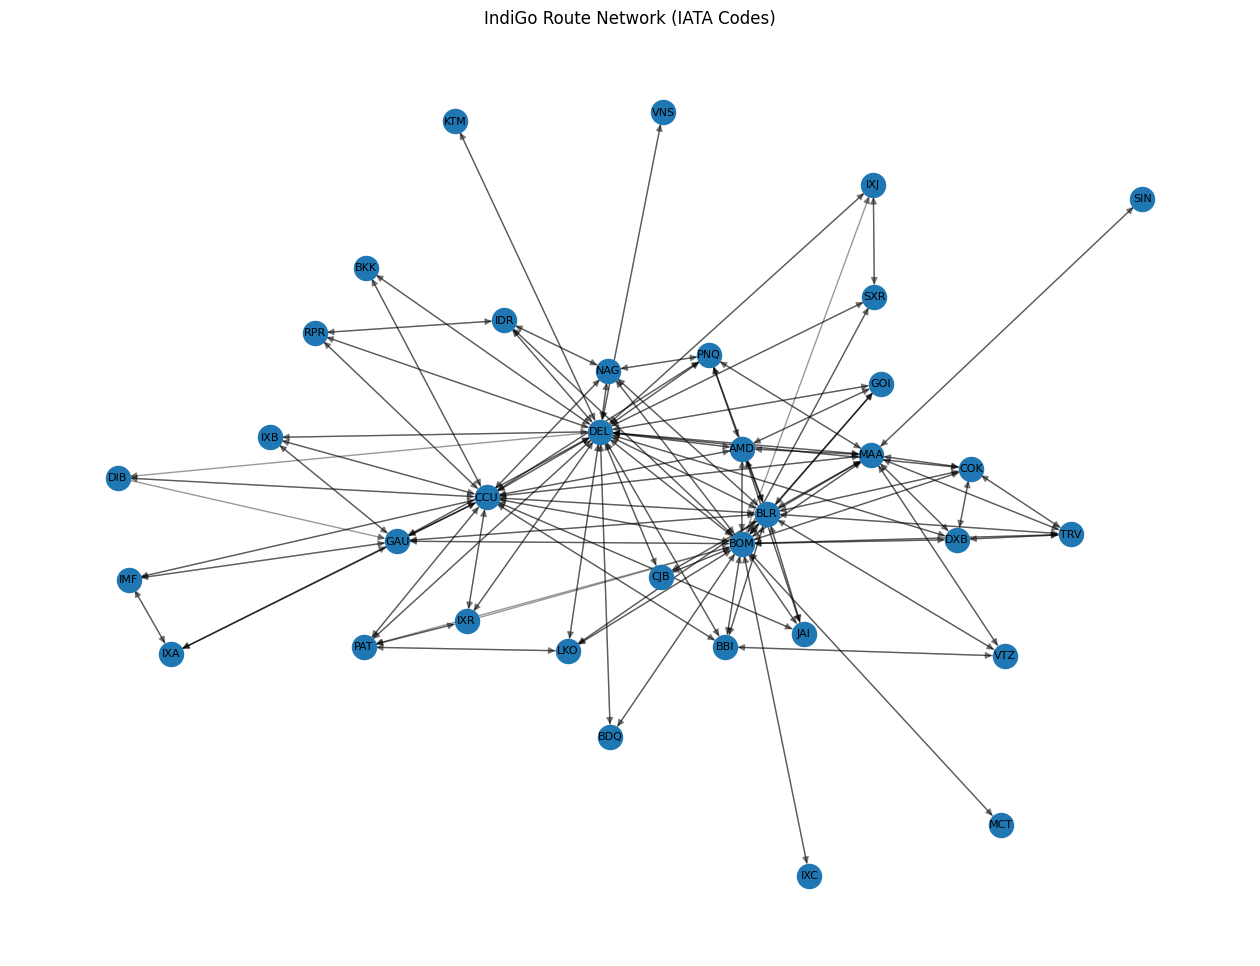

In [ ]:
plt.figure(figsize=(16,12))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=300
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.4
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=airport_labels,
    font_size=8
)

plt.title("IndiGo Route Network (IATA Codes)")
plt.axis("off")
plt.show()

In [ ]:
degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame(
    degree_centrality.items(),
    columns=[
        "Airport",
        "Degree_Centrality"
    ]
)

degree_df.head()

,Airport,Degree_Centrality
0,Sardar Vallabhbhai Patel International Airport,0.470588
1,Kempegowda International Airport,0.882353
2,Chhatrapati Shivaji International Airport,1.264706
3,Netaji Subhash Chandra Bose International Airport,1.058824
4,Indira Gandhi International Airport,1.500000


In [ ]:
degree_df = degree_df.sort_values(
    "Degree_Centrality",
    ascending=False
)

degree_df.head(20)

,Airport,Degree_Centrality
4,Indira Gandhi International Airport,1.500000
2,Chhatrapati Shivaji International Airport,1.264706
3,Netaji Subhash Chandra Bose International Airport,1.058824
1,Kempegowda International Airport,0.882353
7,Chennai International Airport,0.705882
0,Sardar Vallabhbhai Patel International Airport,0.470588
14,Lokpriya Gopinath Bordoloi International Airport,0.441176
13,Cochin International Airport,0.352941
16,Dr. Babasaheb Ambedkar International Airport,0.352941
8,Pune Airport,0.352941


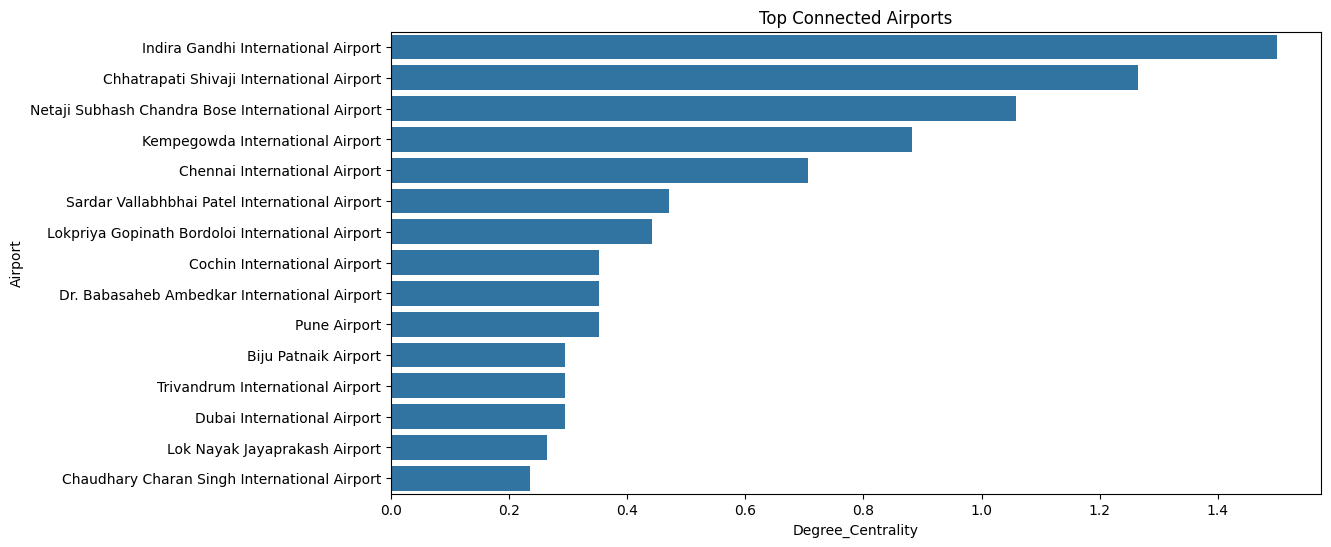

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=degree_df.head(15),
    x="Degree_Centrality",
    y="Airport"
)

plt.title(
    "Top Connected Airports"
)

plt.show()

In [ ]:
betweenness = nx.betweenness_centrality(
    G
)

between_df = pd.DataFrame(
    betweenness.items(),
    columns=[
        "Airport",
        "Betweenness"
    ]
)

between_df.head()

,Airport,Betweenness
0,Sardar Vallabhbhai Patel International Airport,0.007054
1,Kempegowda International Airport,0.069089
2,Chhatrapati Shivaji International Airport,0.256007
3,Netaji Subhash Chandra Bose International Airport,0.180723
4,Indira Gandhi International Airport,0.377532


In [ ]:
between_df = between_df.sort_values(
    "Betweenness",
    ascending=False
)

between_df.head(10)

,Airport,Betweenness
4,Indira Gandhi International Airport,0.377532
2,Chhatrapati Shivaji International Airport,0.256007
3,Netaji Subhash Chandra Bose International Airport,0.180723
7,Chennai International Airport,0.094585
1,Kempegowda International Airport,0.069089
14,Lokpriya Gopinath Bordoloi International Airport,0.042066
9,Biju Patnaik Airport,0.010676
0,Sardar Vallabhbhai Patel International Airport,0.007054
16,Dr. Babasaheb Ambedkar International Airport,0.003820
24,Lok Nayak Jayaprakash Airport,0.002815


In [ ]:
airport_codes = (
    indigo[
        ["Source_Airport_Name", "Source_Airport"]
    ]
    .drop_duplicates()
)

airport_codes.columns = [
    "Airport",
    "IATA"
]

between_df = between_df.merge(
    airport_codes,
    on="Airport",
    how="left"
)

between_df[
    ["IATA", "Airport", "Betweenness"]
].head(10)

,IATA,Airport,Betweenness
0,DEL,Indira Gandhi International Airport,0.377532
1,BOM,Chhatrapati Shivaji International Airport,0.256007
2,CCU,Netaji Subhash Chandra Bose International Airport,0.180723
3,MAA,Chennai International Airport,0.094585
4,BLR,Kempegowda International Airport,0.069089
5,GAU,Lokpriya Gopinath Bordoloi International Airport,0.042066
6,BBI,Biju Patnaik Airport,0.010676
7,AMD,Sardar Vallabhbhai Patel International Airport,0.007054
8,NAG,Dr. Babasaheb Ambedkar International Airport,0.003820
9,PAT,Lok Nayak Jayaprakash Airport,0.002815


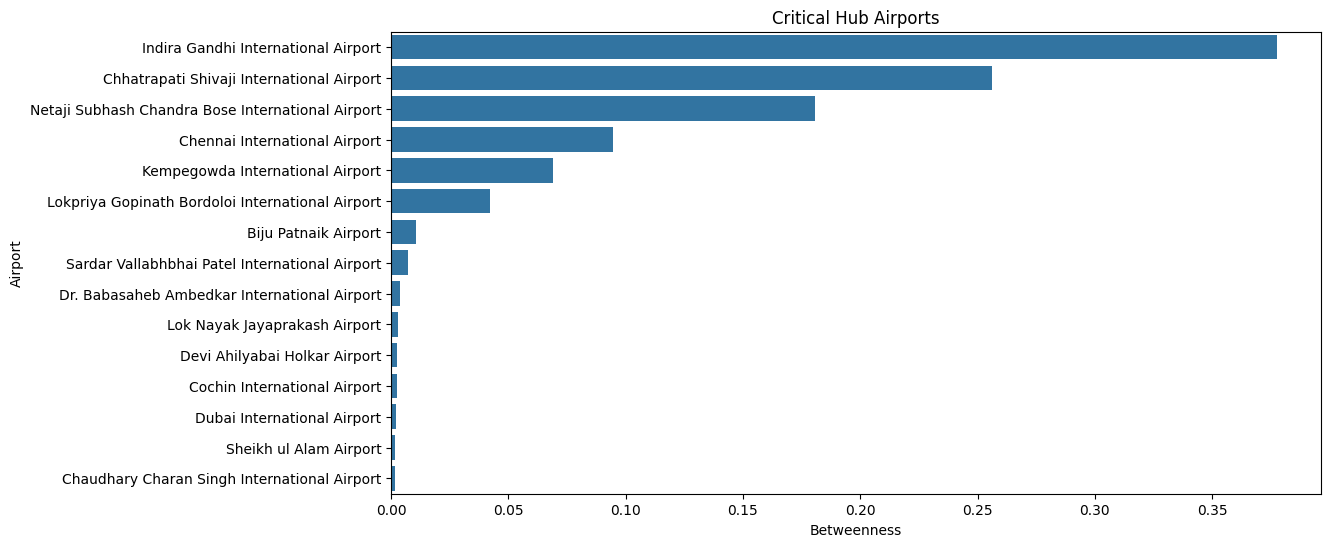

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=between_df.head(15),
    x="Betweenness",
    y="Airport"
)

plt.title(
    "Critical Hub Airports"
)

plt.show()

In [ ]:
closeness = nx.closeness_centrality(G)

close_df = pd.DataFrame(
    closeness.items(),
    columns=[
        "Airport",
        "Closeness"
    ]
)

close_df.head()

,Airport,Closeness
0,Sardar Vallabhbhai Patel International Airport,0.566667
1,Kempegowda International Airport,0.641509
2,Chhatrapati Shivaji International Airport,0.723404
3,Netaji Subhash Chandra Bose International Airport,0.680000
4,Indira Gandhi International Airport,0.790698


In [ ]:
close_df = close_df.sort_values(
    "Closeness",
    ascending=False
)

close_df.head(20)

,Airport,Closeness
4,Indira Gandhi International Airport,0.790698
2,Chhatrapati Shivaji International Airport,0.723404
3,Netaji Subhash Chandra Bose International Airport,0.680000
1,Kempegowda International Airport,0.641509
7,Chennai International Airport,0.607143
0,Sardar Vallabhbhai Patel International Airport,0.566667
14,Lokpriya Gopinath Bordoloi International Airport,0.557377
16,Dr. Babasaheb Ambedkar International Airport,0.539683
8,Pune Airport,0.531250
9,Biju Patnaik Airport,0.531250


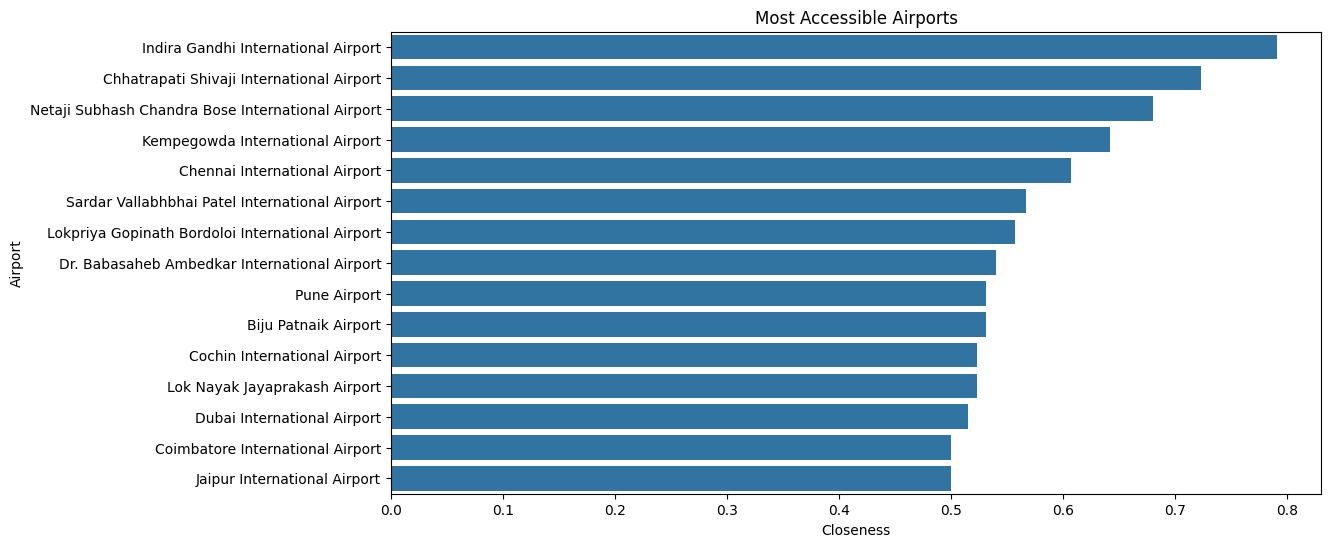

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=close_df.head(15),
    x="Closeness",
    y="Airport"
)

plt.title(
    "Most Accessible Airports"
)

plt.show()

In [ ]:
hub_score = degree_df.merge(
    between_df,
    on="Airport"
)

hub_score = hub_score.merge(
    close_df,
    on="Airport"
)

hub_score.head()

,Airport,Degree_Centrality,Betweenness,IATA,Closeness
0,Indira Gandhi International Airport,1.500000,0.377532,DEL,0.790698
1,Chhatrapati Shivaji International Airport,1.264706,0.256007,BOM,0.723404
2,Netaji Subhash Chandra Bose International Airport,1.058824,0.180723,CCU,0.680000
3,Kempegowda International Airport,0.882353,0.069089,BLR,0.641509
4,Chennai International Airport,0.705882,0.094585,MAA,0.607143


In [ ]:
hub_score["Connectivity_Score"] = (
    hub_score["Degree_Centrality"]*0.4
    +
    hub_score["Betweenness"]*0.4
    +
    hub_score["Closeness"]*0.2
)

In [ ]:
hub_score = hub_score.sort_values(
    "Connectivity_Score",
    ascending=False
)

hub_score.head(20)

,Airport,Degree_Centrality,Betweenness,IATA,Closeness,Connectivity_Score
0,Indira Gandhi International Airport,1.500000,0.377532,DEL,0.790698,0.909153
1,Chhatrapati Shivaji International Airport,1.264706,0.256007,BOM,0.723404,0.752966
2,Netaji Subhash Chandra Bose International Airport,1.058824,0.180723,CCU,0.680000,0.631819
3,Kempegowda International Airport,0.882353,0.069089,BLR,0.641509,0.508879
4,Chennai International Airport,0.705882,0.094585,MAA,0.607143,0.441616
6,Lokpriya Gopinath Bordoloi International Airport,0.441176,0.042066,GAU,0.557377,0.304772
5,Sardar Vallabhbhai Patel International Airport,0.470588,0.007054,AMD,0.566667,0.304390
8,Dr. Babasaheb Ambedkar International Airport,0.352941,0.003820,NAG,0.539683,0.250641
9,Pune Airport,0.352941,0.001070,PNQ,0.531250,0.247854
7,Cochin International Airport,0.352941,0.002465,COK,0.523077,0.246778


In [ ]:
hub_score["Connectivity_Score"] = (
    hub_score["Degree_Centrality"]*0.4
    +
    hub_score["Betweenness"]*0.4
    +
    hub_score["Closeness"]*0.2
)

In [ ]:
hub_score = hub_score.sort_values(
    "Connectivity_Score",
    ascending=False
)

hub_score.head(20)

,Airport,Degree_Centrality,Betweenness,IATA,Closeness,Connectivity_Score
0,Indira Gandhi International Airport,1.500000,0.377532,DEL,0.790698,0.909153
1,Chhatrapati Shivaji International Airport,1.264706,0.256007,BOM,0.723404,0.752966
2,Netaji Subhash Chandra Bose International Airport,1.058824,0.180723,CCU,0.680000,0.631819
3,Kempegowda International Airport,0.882353,0.069089,BLR,0.641509,0.508879
4,Chennai International Airport,0.705882,0.094585,MAA,0.607143,0.441616
6,Lokpriya Gopinath Bordoloi International Airport,0.441176,0.042066,GAU,0.557377,0.304772
5,Sardar Vallabhbhai Patel International Airport,0.470588,0.007054,AMD,0.566667,0.304390
8,Dr. Babasaheb Ambedkar International Airport,0.352941,0.003820,NAG,0.539683,0.250641
9,Pune Airport,0.352941,0.001070,PNQ,0.531250,0.247854
7,Cochin International Airport,0.352941,0.002465,COK,0.523077,0.246778


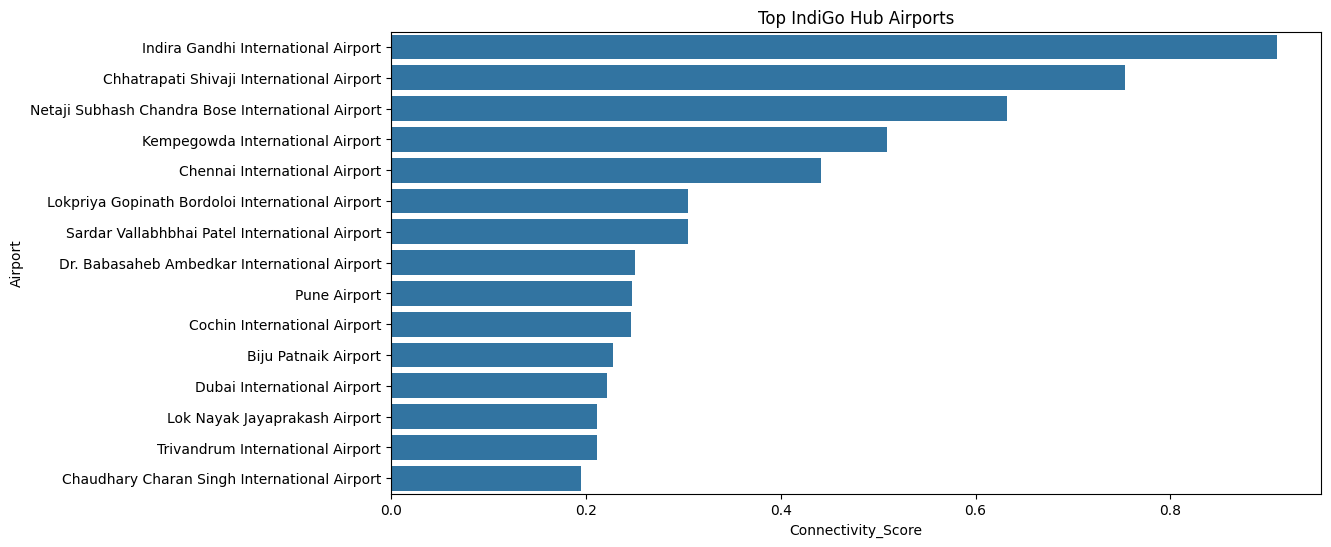

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=hub_score.head(15),
    x="Connectivity_Score",
    y="Airport"
)

plt.title(
    "Top IndiGo Hub Airports"
)

plt.show()

In [ ]:
airport_profit = (
    indigo
    .groupby("Source_Airport_Name")
    ["Profit"]
    .sum()
    .reset_index()
)

airport_profit.columns = [
    "Airport",
    "Total_Profit"
]

airport_profit.head()

,Airport,Total_Profit
0,Agartala Airport,1746154890
1,Bagdogra Airport,578014730
2,Biju Patnaik Airport,1453205160
3,Birsa Munda Airport,-1157123000
4,Chandigarh Airport,-740338260


In [ ]:
hub_profit = hub_score.merge(
    airport_profit,
    on="Airport",
    how="left"
)

hub_profit.head()

,Airport,Degree_Centrality,Betweenness,IATA,Closeness,Connectivity_Score,Total_Profit
0,Indira Gandhi International Airport,1.500000,0.377532,DEL,0.790698,0.909153,19062917780
1,Chhatrapati Shivaji International Airport,1.264706,0.256007,BOM,0.723404,0.752966,18682610775
2,Netaji Subhash Chandra Bose International Airport,1.058824,0.180723,CCU,0.680000,0.631819,4156203170
3,Kempegowda International Airport,0.882353,0.069089,BLR,0.641509,0.508879,336501165
4,Chennai International Airport,0.705882,0.094585,MAA,0.607143,0.441616,7046954625


In [ ]:
hub_profit = hub_profit.sort_values(
    "Total_Profit",
    ascending=False
)

hub_profit.head(20)

,Airport,Degree_Centrality,Betweenness,IATA,Closeness,Connectivity_Score,Total_Profit
0,Indira Gandhi International Airport,1.500000,0.377532,DEL,0.790698,0.909153,19062917780
1,Chhatrapati Shivaji International Airport,1.264706,0.256007,BOM,0.723404,0.752966,18682610775
11,Dubai International Airport,0.294118,0.002109,DXB,0.515152,0.221521,11203724275
4,Chennai International Airport,0.705882,0.094585,MAA,0.607143,0.441616,7046954625
17,Devi Ahilyabai Holkar Airport,0.235294,0.002575,IDR,0.492754,0.193698,6477661205
27,Suvarnabhumi Airport,0.117647,0.000000,BKK,0.478873,0.142833,5238791710
2,Netaji Subhash Chandra Bose International Airport,1.058824,0.180723,CCU,0.680000,0.631819,4156203170
15,Dabolim Airport,0.235294,0.000000,GOI,0.500000,0.194118,3790238475
7,Dr. Babasaheb Ambedkar International Airport,0.352941,0.003820,NAG,0.539683,0.250641,3538251600
20,Sheikh ul Alam Airport,0.176471,0.001664,SXR,0.485714,0.168397,2994415470


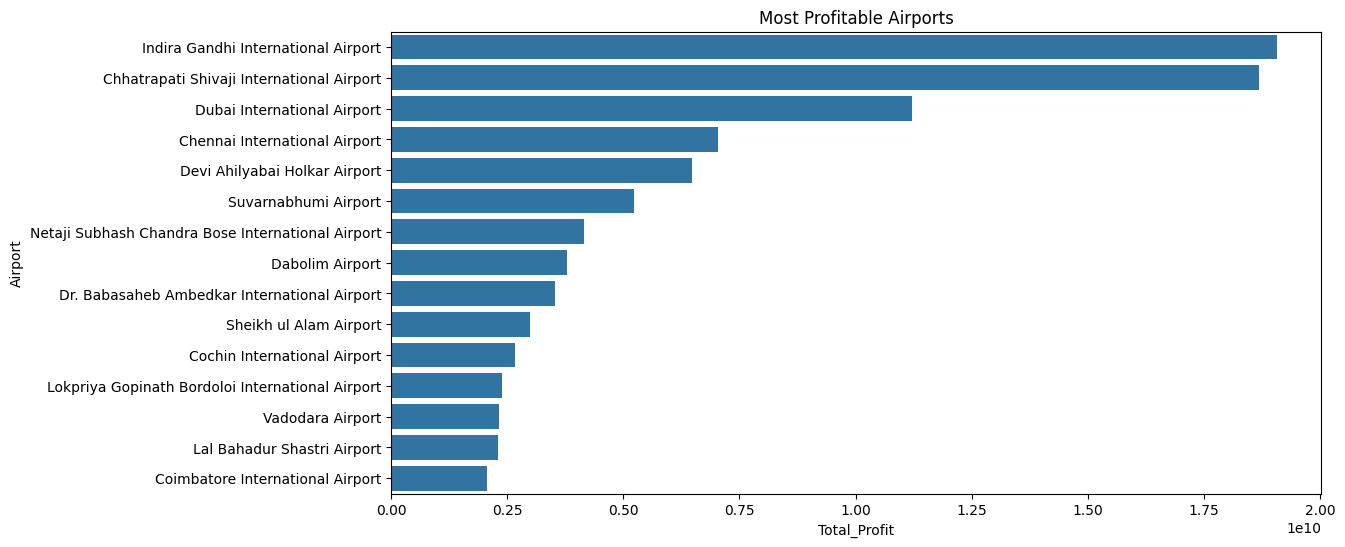

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=hub_profit.head(15),
    x="Total_Profit",
    y="Airport"
)

plt.title(
    "Most Profitable Airports"
)

plt.show()

In [ ]:
hub_profit["Hub_Type"] = np.where(
    hub_profit["Connectivity_Score"] > 0.10,
    "Major Hub",
    "Regional Hub"
)

In [ ]:
hub_profit["Hub_Type"].value_counts()

,count
Hub_Type,
Major Hub,34
Regional Hub,1


In [ ]:
expansion = hub_profit[
    hub_profit["Connectivity_Score"]
    <
    hub_profit["Connectivity_Score"].median()
]

expansion = expansion.sort_values(
    "Total_Profit",
    ascending=False
)

expansion.head(15)

,Airport,Degree_Centrality,Betweenness,IATA,Closeness,Connectivity_Score,Total_Profit,Hub_Type
27,Suvarnabhumi Airport,0.117647,0.000000,BKK,0.478873,0.142833,5238791710,Major Hub
20,Sheikh ul Alam Airport,0.176471,0.001664,SXR,0.485714,0.168397,2994415470,Major Hub
28,Vadodara Airport,0.117647,0.000000,BDQ,0.478873,0.142833,2315259240,Major Hub
31,Lal Bahadur Shastri Airport,0.058824,0.000000,VNS,0.447368,0.113003,2303539820,Major Hub
19,Coimbatore International Airport,0.176471,0.000000,CJB,0.500000,0.170588,2069547080,Major Hub
29,Dibrugarh Airport,0.117647,0.000000,DIB,0.478873,0.142833,1795522600,Major Hub
25,Agartala Airport,0.176471,0.000000,IXA,0.419753,0.154539,1746154890,Major Hub
26,Imphal Airport,0.176471,0.000000,IMF,0.419753,0.154539,986142035,Major Hub
22,Bagdogra Airport,0.176471,0.000000,IXB,0.485714,0.167731,578014730,Major Hub
21,Raipur Airport,0.176471,0.001188,RPR,0.485714,0.168206,366123470,Major Hub


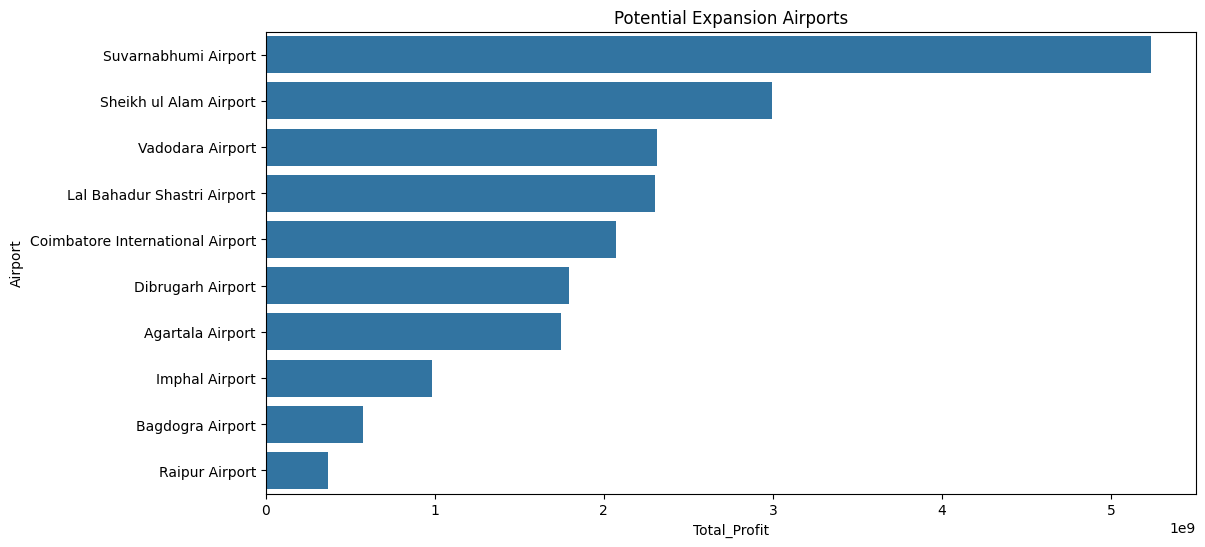

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=expansion.head(10),
    x="Total_Profit",
    y="Airport"
)

plt.title(
    "Potential Expansion Airports"
)

plt.show()

In [ ]:
top_airport = hub_score.iloc[0]["Airport"]

G2 = G.copy()

G2.remove_node(top_airport)

print("Original Nodes:",
      G.number_of_nodes())

print("Remaining Nodes:",
      G2.number_of_nodes())

Original Nodes: 35
Remaining Nodes: 34


In [ ]:
impact = (
    (G.number_of_edges()
    - G2.number_of_edges())
    /
    G.number_of_edges()
) * 100

print(
    f"Network Impact: {impact:.2f}%"
)

Network Impact: 25.63%


In [ ]:
hub_profit.to_csv(
    "indigo_network_intelligence.csv",
    index=False
)

print("File Saved")

File Saved


In [ ]:
print("="*60)

print("INDIGO NETWORK INTELLIGENCE REPORT")

print("="*60)

print(
    "Total Airports:",
    G.number_of_nodes()
)

print(
    "Total Routes:",
    G.number_of_edges()
)

print()

print(
    "Top Hub Airport:"
)

print(
    hub_score.iloc[0]["Airport"]
)

print()

print(
    "Most Profitable Airport:"
)

print(
    hub_profit.iloc[0]["Airport"]
)

print()

print(
    "Network Impact if Top Hub Removed:"
)

print(
    round(impact,2),
    "%"
)

print("="*60)

INDIGO NETWORK INTELLIGENCE REPORT
Total Airports: 35
Total Routes: 199

Top Hub Airport:
Indira Gandhi International Airport

Most Profitable Airport:
Indira Gandhi International Airport

Network Impact if Top Hub Removed:
25.63 %
